# Standard problem 4

## Problem specification

The sample is a thin film cuboid with dimensions:

- length $l_{x} = 500 \,\text{nm}$,
- width $l_{y} = 125 \,\text{nm}$, and
- thickness $l_{z} = 3 \,\text{nm}$.

The material parameters (similar to permalloy) are:

- exchange energy constant $A = 1.3 \times 10^{-11} \,\text{J/m}$,
- magnetisation saturation $M_\text{s} = 8 \times 10^{5} \,\text{A/m}$.

Magnetisation dynamics are governed by the Landau-Lifshitz-Gilbert equation

$$\frac{d\mathbf{m}}{dt} = \underbrace{-\gamma_{0}(\mathbf{m} \times \mathbf{H}_\text{eff})}_\text{precession} + \underbrace{\alpha\left(\mathbf{m} \times \frac{d\mathbf{m}}{dt}\right)}_\text{damping}$$

where $\gamma_{0} = 2.211 \times 10^{5} \,\text{m}\,\text{A}^{-1}\,\text{s}^{-1}$ and Gilbert damping $\alpha=0.02$.

In the standard problem 4, the system is first relaxed at zero external magnetic field and then, starting from the obtained equlibrium configuration, the magnetisation dynamics are simulated for two external magnetic fields $\mathbf{B}_{1} = (-24.6, 4.3, 0.0) \,\text{mT}$ and $\mathbf{B}_{2} = (-35.5, -6.3, 0.0) \,\text{mT}$.

More detailed specification of Standard problem 4 can be found in Ref. 1.

## Simulation

### Import modules
In the first step, we import the required modules.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import constants

import neuralmag as nm

2025-03-26 20:13:18 NeuralMag:INFO [NeuralMag] Version 0.9.1


### Setup mesh and state

In the first stage, we need to setup the mesh and the simulation state. We chose a cell size of $5 \times 5 \times 3 \,\text{nm}^3$ resulting in $100 \times 25 \times 1$ cells simulate for the geometry defined for this standard problem.

In [2]:
mesh = nm.Mesh([100, 25, 1], [5e-9, 5e-9, 3e-9], [0.0, 0.0, 0.0])
state = nm.State(mesh)

2025-03-26 20:13:26 NeuralMag:INFO [Mesh] 3D, 100 x 25 x 1 (size = 5e-09 x 5e-09 x 3e-09)
2025-03-26 20:13:27 NeuralMag:INFO [NeuralMag] Backend set to 'torch'.
2025-03-26 20:13:27 NeuralMag:INFO [NeuralMag] Set default device to 'cpu'.
2025-03-26 20:13:27 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2025-03-26 20:13:27 NeuralMag:INFO [State] Running on device: cpu (dtype = torch.float32, backend = torch)


### Setup material parameters and define initial magnetization
In the next step, we set the material parameters $M_s$, $A$ and $\alpha$ according to the requirements of the standard problem.

In [3]:
state.material.Ms = 8e5
state.material.A = 1.3e-11
state.material.alpha = 0.02

We have to provide an initial magnetisation configuration that is going to be relaxed subsequently. We choose the uniform configuration in xy-direction that is know to relax into the requires s-state.

In [4]:
state.m = nm.VectorFunction(state).fill((0.5**0.5, 0.5**0.5, 0))

### Register effectiv-field contributions
Now we initialize the effecitive field contributions that are required for the relaxation of the initial magnetization. Namely, we set up a total field consisting of the exchange field and the demagnetization field.

In [5]:
nm.ExchangeField().register(state, "exchange")
nm.DemagField().register(state, "demag")
nm.TotalField("exchange", "demag").register(state)

2025-03-26 20:13:40 NeuralMag:INFO [ExchangeField] Generate torch core methods
Generating...: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:00<00:00, 101.75it/s]
2025-03-26 20:14:17 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange')
2025-03-26 20:14:17 NeuralMag:INFO [DemagField] Generate torch core methods
2025-03-26 20:14:22 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag')
2025-03-26 20:14:22 NeuralMag:INFO [DemagField]: Set up demag tensor
2025-03-26 20:14:22 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')


### Minimize energy to find the initial stable state
We initialze the LLG solver and use the ```relax``` method in order relax the system into the stable s-state configuration.

In [6]:
llg = nm.LLGSolver(state)
llg.relax()

2025-03-26 20:14:33 NeuralMag:INFO [LLGSolverTorch] Initialize RHS function
2025-03-26 20:15:52 NeuralMag:INFO [LLGSolverTorch] Start relaxation, initial energy E = 1.78528e-18 J
2025-03-26 20:22:18 NeuralMag:INFO [LLGSolverTorch] Relaxation finished, final energy E = 6.34137e-19 J


### Apply external field
In the next step we initialize the an external field to switch the magnetization as defined in the standard problem. In order to include this additional field, we update the total field and reset the LLG solver.

In [7]:
# Setup Zeeman field
h_ext = nm.VectorFunction(state).fill(
    [-24.6e-3 / constants.mu_0, 4.3e-3 / constants.mu_0, 0.0]
)
nm.ExternalField(h_ext).register(state, "external")

# Update total field
nm.TotalField("exchange", "demag", "external").register(state)

# Reset LLGSolver
llg.reset()

2025-03-26 20:22:18 NeuralMag:INFO [ExternalField] Generate torch core methods
2025-03-26 20:22:24 NeuralMag:INFO [ExternalField] Register state methods (field: 'h_external', energy: 'E_external')
2025-03-26 20:22:24 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E')
2025-03-26 20:22:24 NeuralMag:INFO [LLGSolverTorch] Initialize RHS function


### Simulate switching
Finally, we can run the switching simulation using the LLGSolver. We run the magnetisation evolution for $t=1 \,\text{ns}$. We set up a logger to save the averaged magnetization as well as a time series of the full magnetization configuration and log the simulation state every $10\,\text{ps}$.

In [11]:
logger = nm.Logger("data", ["t", "m"], ["m"])
while state.t < 1e-9:
    llg.step(1.0e-11)
    logger.log(state)

### Postprocessing

Finally, we want to plot the average magnetization configuration as a function of time `t`:

Text(0, 0.5, 'm_x')

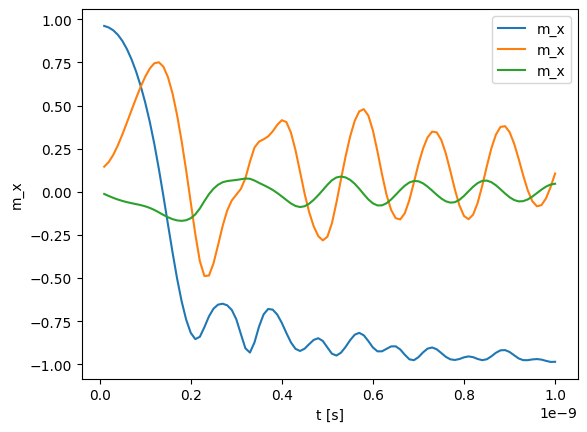

In [10]:
data = np.loadtxt("data/log.dat")
plt.plot(data[:, 0], data[:, 1], label="m_x")
plt.plot(data[:, 0], data[:, 2], label="m_x")
plt.plot(data[:, 0], data[:, 3], label="m_x")
plt.legend()
plt.xlabel("t [s]")
plt.ylabel("m_x")

## References

[1] µMAG Site Directory: http://www.ctcms.nist.gov/~rdm/mumag.org.html
    
This tutorial was adapted from [Ubermag](https://ubermag.github.io/).